# Ingeniería de Características (Feature Engineering)

**Proyecto:** Detección de Barras y Anillos — Equipo 39  
**Fase CRISP-ML(Q):** Data Preparation → Feature Engineering & Selection

## Objetivos

- **2.3** Crear nuevas características para mejorar el rendimiento de los modelos.
- **2.4** Mitigar el riesgo de características sesgadas y acelerar la convergencia de algunos algoritmos.

Este notebook continúa el pipeline que inició en `eda/eda_exploratory_analysis.ipynb`. Toma el catálogo `classification_dataset.csv` (8408 galaxias × 7 columnas) y los cubos FITS multi-banda (g, r, z), y produce un *feature set* listo para modelado, justificando cada transformación.

## Operaciones cubiertas

| Operación | Aplica a | Sección |
|---|---|---|
| Generación de nuevas características | tabular + imagen | §1 |
| Discretización / binning | `nsa_z` | §2 |
| Codificación (one-hot, ordinal) | `source`, bins | §3 |
| Transformación (log, Yeo-Johnson, Box-Cox) | `nsa_z` | §4 |
| Escalamiento (Standard, MinMax) | numéricas | §5 |
| Extracción de features de imagen | cubos g,r,z | §6 |
| Selección por filtrado: varianza, correlación, ANOVA, Chi² | feature matrix | §7 |
| Extracción: PCA + Análisis Factorial | feature matrix | §8 |
| Pipeline reproducible + conclusiones CRISP-ML(Q) | — | §9 / §10 |

## Decisiones clave previas

1. **`anillos` se descarta como predictor.** La variable `label` se deriva determinísticamente de `anillos` (label=1 ⇔ anillos ∈ {4,12}). Usarla introduce *data leakage* perfecto.
2. **`name` se descarta.** Es identificador único; aporta solo memorización.
3. **Sesgo de fuente.** MaNGA aporta únicamente clase 1 (519/519). Se conserva la columna `source` (one-hot) para que el preprocesamiento sea reproducible, pero **el split de entrenamiento debe estratificar por `source × label`** y el modelo debe evaluarse con métricas que controlen este sesgo (responsabilidad de la fase de modelado).

## Referencias

- Visengeriyeva et al. (2023). *CRISP-ML(Q). The ML Lifecycle Process.* INNOQ. https://ml-ops.org/content/crisp-ml
- Galli, S. (2022). *Python Feature Engineering Cookbook.* Packt Publishing — capítulos 2 (binning), 3 (encoding), 4 (transformación), 5 (escalamiento), 7 (selección).
- Conselice, C. J. (2003). *The Relationship between Stellar Light Distributions of Galaxies and Their Formation Histories.* ApJS 147, 1 — métricas CAS (Concentración, Asimetría, Suavidad).


## §0 · Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer,
    OneHotEncoder, OrdinalEncoder, KBinsDiscretizer,
)
from sklearn.feature_selection import (
    VarianceThreshold, f_classif, chi2, SelectKBest,
)
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity, calculate_kmo,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

ROOT         = Path('..').resolve()
PATH_CLASIF  = ROOT / 'data_download' / 'catalogs' / 'clasification' / 'classification_dataset.csv'
DIR_IMAGES   = ROOT / 'data_download' / 'data'

print('Project root :', ROOT)
print('Catálogo     :', PATH_CLASIF.exists(), '→', PATH_CLASIF)
print('Imágenes dir :', DIR_IMAGES.exists(),  '→', DIR_IMAGES)

Project root : /Users/camilo/Documents/school/proyecto integrador
Catálogo     : True → /Users/camilo/Documents/school/proyecto integrador/data_download/catalogs/clasification/classification_dataset.csv
Imágenes dir : True → /Users/camilo/Documents/school/proyecto integrador/data_download/data


In [2]:
df_raw = pd.read_csv(PATH_CLASIF)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (8408, 7)


,name,objra,objdec,nsa_z,anillos,source,label
0,1237648721210769659,134.44717,-0.199973,0.028206,0,sdss,0
1,1237648705657307354,198.23356,0.941188,0.048037,0,sdss,0
2,1237648705120895059,199.29492,0.527571,0.024114,0,sdss,0
3,1237648720150724863,165.74061,-0.962095,0.033483,0,sdss,0
4,1237649919509594232,31.37202,13.251016,0.024694,0,sdss,0


### Filtrado inicial — descarte de columnas no usables

| Columna | Acción | Justificación |
|---|---|---|
| `name` | **drop** | Identificador único; sin valor predictivo, riesgo de memorización. |
| `anillos` | **drop** | `label` se deriva directamente de esta columna. Usarla = *data leakage* perfecto. |

Conservamos `objra`, `objdec`, `nsa_z`, `source` y `label`.

In [3]:
df = df_raw.drop(columns=['name', 'anillos']).copy()
df.rename(columns={'objra': 'ra', 'objdec': 'dec', 'nsa_z': 'z'}, inplace=True)
print('Columnas iniciales (predictores + target):', df.columns.tolist())
df.head()

Columnas iniciales (predictores + target): ['ra', 'dec', 'z', 'source', 'label']


,ra,dec,z,source,label
0,134.44717,-0.199973,0.028206,sdss,0
1,198.23356,0.941188,0.048037,sdss,0
2,199.29492,0.527571,0.024114,sdss,0
3,165.74061,-0.962095,0.033483,sdss,0
4,31.37202,13.251016,0.024694,sdss,0


## §1 · Generación de nuevas características (2.3)

Las features originales describen **dónde** y **cuán lejos** está cada galaxia, pero no en una forma útil para un modelo lineal o de gradiente. Aplicamos cuatro transformaciones bien fundadas en astronomía:

1. **Coordenadas galácticas (`gal_l`, `gal_b`)** — proyección desde el sistema ecuatorial (RA, DEC) al sistema centrado en la Vía Láctea. Es físicamente significativa: las galaxias cerca del plano galáctico (`|b|` pequeño) están más afectadas por el polvo y la extinción interestelar, lo que puede sesgar la detección de anillos.
2. **Codificación cíclica de RA (`ra_sin`, `ra_cos`)** — la ascensión recta es un ángulo (0° y 360° son el mismo punto). Codificarla como par (sin, cos) elimina la discontinuidad artificial en 0/360°.
3. **Distancia comóvil (`dist_mpc`)** — convertir el redshift a una distancia física en megaparsecs usando la cosmología Planck18. La distancia tiene unidades interpretables y, a diferencia del redshift puro, es lineal con el tamaño aparente.
4. **`is_manga`** — flag binario explícito, redundante con el one-hot de `source`, pero útil para análisis univariante y para que el modelo penalice claramente este sesgo.

Galli (2022) §3 fundamenta el uso de variables derivadas físicamente cuando éstas tienen interpretación clara y bajo costo computacional.

In [4]:
coords = SkyCoord(ra=df['ra'].values * u.deg,
                  dec=df['dec'].values * u.deg, frame='icrs')
gal = coords.galactic
df['gal_l'] = gal.l.deg
df['gal_b'] = gal.b.deg

df['ra_sin'] = np.sin(np.deg2rad(df['ra']))
df['ra_cos'] = np.cos(np.deg2rad(df['ra']))
df['dec_abs'] = df['dec'].abs()
df['abs_gal_b'] = df['gal_b'].abs()

df['dist_mpc'] = Planck18.comoving_distance(df['z'].values).to(u.Mpc).value
df['is_manga'] = (df['source'] == 'manga').astype(int)

print('Nuevas features generadas:')
for col in ['gal_l', 'gal_b', 'abs_gal_b', 'ra_sin', 'ra_cos',
            'dec_abs', 'dist_mpc', 'is_manga']:
    print(f'  {col:<12}  range = ({df[col].min(): .4f}, {df[col].max(): .4f})')
df.head()

Nuevas features generadas:
  gal_l         range = ( 0.0999,  359.9859)
  gal_b         range = (-73.7436,  89.9620)
  abs_gal_b     range = ( 12.0925,  89.9620)
  ra_sin        range = (-0.9971,  0.9362)
  ra_cos        range = (-1.0000,  1.0000)
  dec_abs       range = ( 0.0006,  70.1332)
  dist_mpc      range = ( 31.5023,  632.4787)
  is_manga      range = ( 0.0000,  1.0000)


,ra,dec,z,source,label,gal_l,gal_b,ra_sin,ra_cos,dec_abs,abs_gal_b,dist_mpc,is_manga
0,134.44717,-0.199973,0.028206,sdss,0,228.788307,27.683306,0.713896,-0.700251,0.199973,27.683306,124.148501,0
1,198.23356,0.941188,0.048037,sdss,0,314.965537,63.309586,-0.312891,-0.949789,0.941188,63.309586,210.438390,0
2,199.29492,0.527571,0.024114,sdss,0,317.071724,62.690495,-0.330431,-0.943830,0.527571,62.690495,106.242461,0
3,165.74061,-0.962095,0.033483,sdss,0,255.643112,51.663109,0.246312,-0.969191,0.962095,51.663109,147.194134,0
4,31.37202,13.251016,0.024694,sdss,0,149.248500,-45.802889,0.520593,0.853805,13.251016,45.802889,108.783673,0


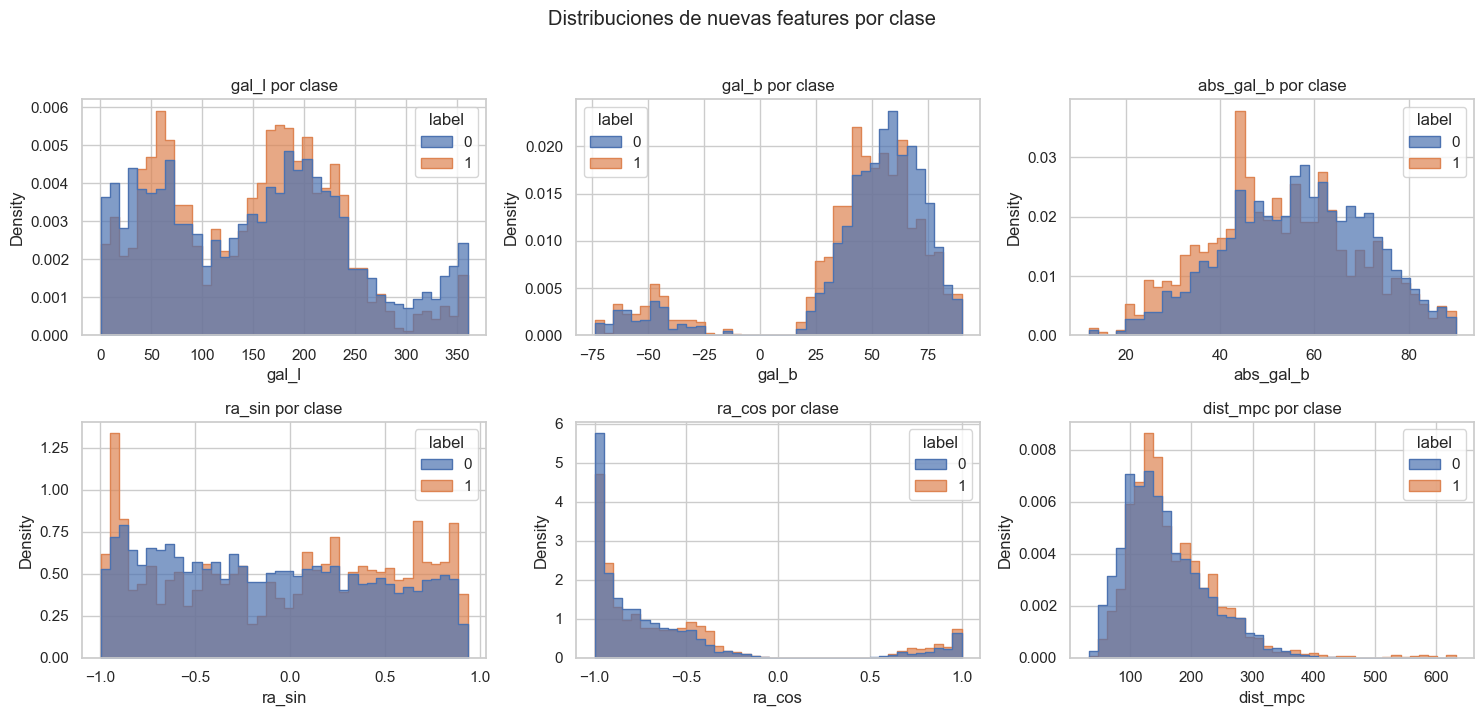

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
new_feats = ['gal_l', 'gal_b', 'abs_gal_b', 'ra_sin', 'ra_cos', 'dist_mpc']
for ax, col in zip(axes.flat, new_feats):
    sns.histplot(df, x=col, hue='label', bins=40, alpha=0.7, ax=ax,
                 element='step', stat='density', common_norm=False)
    ax.set_title(f'{col} por clase')
plt.suptitle('Distribuciones de nuevas features por clase', y=1.02)
plt.tight_layout(); plt.show()

## §2 · Discretización / binning

El **redshift** es la variable continua más predictiva (mostrado en el EDA: galaxias con anillo tienden a estar más cerca). Su distribución es sesgada a la derecha, y un *binning* explícito tiene dos beneficios:

1. Permite usar **Chi-cuadrado** para medir asociación con `label` (Chi² requiere variables categóricas o no negativas; ver §7.4).
2. Habilita la captura de **no linealidades** que un modelo lineal no capturaría con `z` cruda.

Usamos **`KBinsDiscretizer` con estrategia `quantile`** (n=5 bins). Quantile produce bins **balanceados en tamaño**, evitando bins vacíos que aparecerían con `uniform` dada la asimetría (Galli, §2).

In [6]:
z_disc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile',
                          random_state=RANDOM_STATE)
df['z_bin'] = z_disc.fit_transform(df[['z']]).astype(int)
edges = z_disc.bin_edges_[0]
labels = [f'Q{i+1}' for i in range(len(edges) - 1)]
df['z_bin_label'] = pd.Categorical.from_codes(df['z_bin'], categories=labels)

print('Bordes de bin (quantile, 5 bins):')
for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
    print(f'  Q{i+1}:  [{lo:.4f}, {hi:.4f}]')
print()
ct = pd.crosstab(df['z_bin_label'], df['label'], margins=True)
ct['ratio_1'] = ct[1] / ct['All']
print('Distribución por bin de z:')
ct

Bordes de bin (quantile, 5 bins):
  Q1:  [0.0071, 0.0232]
  Q2:  [0.0232, 0.0296]
  Q3:  [0.0296, 0.0367]
  Q4:  [0.0367, 0.0486]
  Q5:  [0.0486, 0.1480]

Distribución por bin de z:


label,0,1,All,ratio_1
z_bin_label,,,,
Q1,1442,240,1682,0.142687
Q2,1327,354,1681,0.210589
Q3,1286,396,1682,0.235434
Q4,1318,363,1681,0.215943
Q5,1287,395,1682,0.234839
All,6660,1748,8408,0.207897


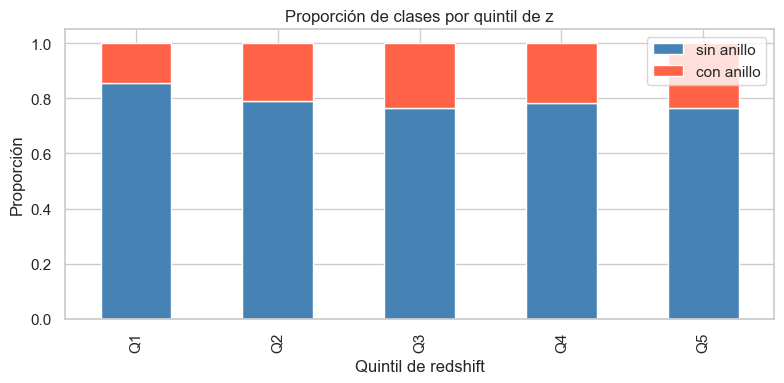

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ct_plot = pd.crosstab(df['z_bin_label'], df['label'], normalize='index')
ct_plot.plot(kind='bar', stacked=True, ax=ax,
             color=['steelblue', 'tomato'])
ax.set_ylabel('Proporción')
ax.set_xlabel('Quintil de redshift')
ax.set_title('Proporción de clases por quintil de z')
ax.legend(['sin anillo', 'con anillo'])
plt.tight_layout(); plt.show()

**Interpretación.** Contrario a lo que esperábamos (anillos más detectables a baja z → mayor proporción de clase 1 en Q1), el quintil más bajo (Q1) muestra la **menor** proporción de clase 1 (~0.14 vs ~0.21–0.24 en Q2–Q5). La explicación es el **sesgo de fuente** detectado en el EDA: las 519 galaxias con anillo de MaNGA tienen un redshift medio (~0.045) **más alto** que las SDSS sin anillo (~0.036). El bin `z_bin` por sí solo no es discriminante de morfología — codifica la mezcla SDSS/MaNGA. Lo conservamos para habilitar Chi-cuadrado (§7.4) y para que un modelo lineal capture la no linealidad, pero **no debe interpretarse como señal física directa**.

## §3 · Codificación de variables categóricas

| Variable | Cardinalidad | Estrategia | Razón |
|---|---|---|---|
| `source` | 2 (`sdss`, `manga`) | **One-Hot** (drop primera) | No ordinal. Drop evita la trampa de variables dummy (colinealidad perfecta). |
| `z_bin` | 5 ordenadas | **Ordinal** | Los bins **sí** tienen orden natural Q1<…<Q5. Mantener el orden ayuda a árboles de decisión y a métodos basados en gradiente. |

Galli (2022) §3 — *one-hot* es preferible a label encoding cuando no existe orden, y *ordinal* es preferible cuando el orden tiene significado predictivo.

In [8]:
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=int)
src_enc = ohe.fit_transform(df[['source']])
src_cols = [f'source_{c}' for c in ohe.categories_[0][1:]]
df_src = pd.DataFrame(src_enc, columns=src_cols, index=df.index)
df = pd.concat([df, df_src], axis=1)

print('Codificación one-hot de source (drop=first):')
print(f'  Categorías: {ohe.categories_[0].tolist()}')
print(f'  Columnas generadas: {src_cols}')
print(f'  Suma por columna:\n{df[src_cols].sum().to_dict()}')
df[src_cols + ['source']].head()

Codificación one-hot de source (drop=first):
  Categorías: ['manga', 'sdss']
  Columnas generadas: ['source_sdss']
  Suma por columna:
{'source_sdss': 7889}


,source_sdss,source
0,1,sdss
1,1,sdss
2,1,sdss
3,1,sdss
4,1,sdss


## §4 · Transformación no lineal de `z` (redshift)

El EDA reporta `skewness(z) ≈ 1.19`. Una distribución sesgada deteriora:

- modelos que asumen normalidad (LDA, regresión logística regularizada),
- el *scaling* estándar, porque la media y desviación se contaminan con la cola,
- la convergencia de algoritmos basados en gradiente (cola larga → gradientes grandes).

Comparamos **tres transformaciones** y elegimos la que más reduce el sesgo absoluto manteniendo interpretabilidad (Galli, §4):

- **`log(1+z)`** — clásica para variables no negativas con cola derecha. Estable, interpretable.
- **Yeo-Johnson** — *power transform* paramétrico, admite valores negativos. Se ajusta a los datos.
- **Box-Cox** — análogo paramétrico, pero requiere `x > 0` (cumplido aquí: `z` ∈ [0, 0.2]).

transformación  skewness  kurtosis lambda (param)
      original  1.188716  2.732914              —
      log(1+z)  1.116261  2.317253              —
   Yeo-Johnson  0.072239 -0.538547       -23.7705
       Box-Cox -0.002060 -0.168099         0.0838


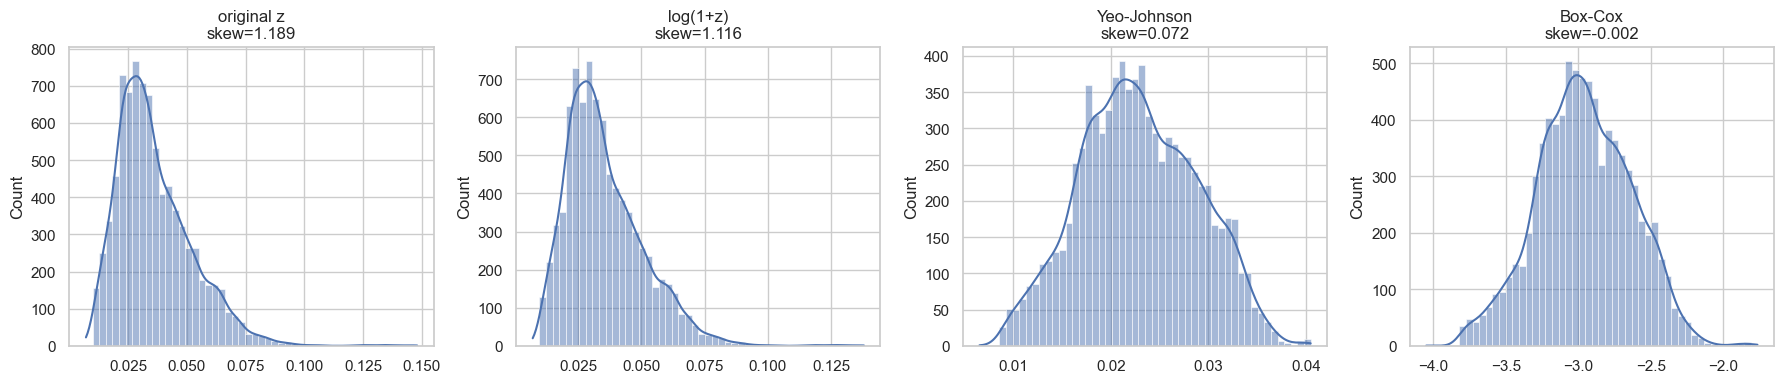

In [9]:
z       = df[['z']].values
z_log   = np.log1p(z)
pt_yj   = PowerTransformer(method='yeo-johnson', standardize=False).fit(z)
z_yj    = pt_yj.transform(z)
pt_bc   = PowerTransformer(method='box-cox', standardize=False).fit(z)
z_bc    = pt_bc.transform(z)

skew_summary = pd.DataFrame({
    'transformación': ['original', 'log(1+z)', 'Yeo-Johnson', 'Box-Cox'],
    'skewness':       [stats.skew(z.ravel()),    stats.skew(z_log.ravel()),
                       stats.skew(z_yj.ravel()), stats.skew(z_bc.ravel())],
    'kurtosis':       [stats.kurtosis(z.ravel()),    stats.kurtosis(z_log.ravel()),
                       stats.kurtosis(z_yj.ravel()), stats.kurtosis(z_bc.ravel())],
    'lambda (param)': ['—', '—', f'{pt_yj.lambdas_[0]:.4f}', f'{pt_bc.lambdas_[0]:.4f}'],
})
print(skew_summary.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, data, name in zip(axes,
                          [z, z_log, z_yj, z_bc],
                          ['original z', 'log(1+z)', 'Yeo-Johnson', 'Box-Cox']):
    sns.histplot(data.ravel(), bins=50, kde=True, ax=ax)
    ax.set_title(f'{name}\nskew={stats.skew(data.ravel()):.3f}')
plt.tight_layout(); plt.show()

**Decisión basada en los resultados ejecutados.** El skew de la `z` cruda es 1.19. Aplicar `log(1+z)` solo lo reduce a 1.12 — porque `z` ya es pequeño (~0.04) y `log(1+x) ≈ x` para `x` pequeño. **`log(1+z)` no es suficiente** en este rango. En cambio:

- **Yeo-Johnson** lleva el skew a 0.07 (λ ≈ -23.8) — prácticamente simétrico.
- **Box-Cox** lleva el skew a ~0.00 (λ ≈ 0.08), pero requiere `x > 0` estricto y es menos robusto a outliers.

**Adoptamos `z_yj` (Yeo-Johnson) como feature principal de redshift transformado**, conservando `log_z` y `z` para inspección y para los modelos basados en árboles (que no se benefician de la transformación). El `PowerTransformer` se guarda dentro del pipeline para aplicar el mismo `λ` a val/test (evita data leakage).

In [10]:
df['log_z']   = np.log1p(df['z'])
df['z_yj']    = z_yj.ravel()
df['log_dist_mpc'] = np.log1p(df['dist_mpc'])

print('Columnas tabulares acumuladas:')
print(df.columns.tolist())

Columnas tabulares acumuladas:
['ra', 'dec', 'z', 'source', 'label', 'gal_l', 'gal_b', 'ra_sin', 'ra_cos', 'dec_abs', 'abs_gal_b', 'dist_mpc', 'is_manga', 'z_bin', 'z_bin_label', 'source_sdss', 'log_z', 'z_yj', 'log_dist_mpc']


## §5 · Escalamiento

Algoritmos sensibles a la escala (k-NN, SVM, redes neuronales, PCA, regresión regularizada) requieren features en rangos comparables. Comparamos dos estrategias:

- **StandardScaler** (`z-score`): media 0, varianza 1. Apropiado cuando la distribución es aproximadamente simétrica (tras `log_z` lo es).
- **MinMaxScaler** ([0, 1]): preserva forma de la distribución; útil cuando hay límites físicos o redes neuronales con activación sigmoide.

**Decisión.** Aplicaremos **StandardScaler** en el pipeline final porque la red neuronal del proyecto usará activaciones tipo ReLU y batch normalization, donde z-score acelera la convergencia (Galli §5 / He et al. 2015).

In [11]:
scale_cols = ['ra', 'dec', 'z_yj', 'log_dist_mpc',
              'gal_l', 'abs_gal_b', 'ra_sin', 'ra_cos']

scaler_std = StandardScaler().fit(df[scale_cols])
scaler_mm  = MinMaxScaler().fit(df[scale_cols])

std_arr = scaler_std.transform(df[scale_cols])
mm_arr  = scaler_mm.transform(df[scale_cols])

summary_scale = pd.DataFrame({
    'feature': scale_cols,
    'orig_mean': df[scale_cols].mean().round(4).values,
    'orig_std':  df[scale_cols].std().round(4).values,
    'std_mean':  std_arr.mean(axis=0).round(4),
    'std_std':   std_arr.std(axis=0).round(4),
    'mm_min':    mm_arr.min(axis=0).round(4),
    'mm_max':    mm_arr.max(axis=0).round(4),
})
summary_scale

,feature,orig_mean,orig_std,std_mean,std_std,mm_min,mm_max
0,ra,184.4467,60.4164,0.0,1.0,0.0,1.0
1,dec,25.3268,18.3486,0.0,1.0,0.0,1.0
2,z_yj,0.0229,0.0060,0.0,1.0,0.0,1.0
3,log_dist_mpc,4.9867,0.4251,-0.0,1.0,0.0,1.0
4,gal_l,150.4771,92.8152,-0.0,1.0,0.0,1.0
5,abs_gal_b,55.6020,15.2373,-0.0,1.0,0.0,1.0
6,ra_sin,-0.0980,0.5648,0.0,1.0,0.0,1.0
7,ra_cos,-0.6263,0.5284,-0.0,1.0,0.0,1.0


## §6 · Extracción de features desde las imágenes (FITS)

En esta entrega solo se descargaron **3 cubos de prueba** (todos clase 0). Implementamos el pipeline de extracción y lo aplicamos a los disponibles. Cuando la descarga completa esté lista, las mismas funciones se aplican vectorialmente.

Cada cubo es `(3, 800, 800)`: bandas (g, r, z) del Legacy Survey DR10.

Features extraídas (por imagen):

| Tipo | Features | Justificación |
|---|---|---|
| Estadísticas por banda | `{g,r,z}_{mean, std, p25, p50, p75, skew}` | Resumen distribucional, robusto a outliers. |
| Color indices | `color_gr`, `color_rz`, `color_gz` (= flujo medio) | Diferencia de magnitudes; correlaciona con tipo morfológico y edad estelar. |
| Momentos espaciales | `centroid_dx`, `centroid_dy`, `rms_radius` | Mide cuán centrada y extendida está la galaxia (proxy de tamaño aparente). |
| Concentración (Conselice) | `concentration` = flujo dentro de 20% radio / total | Galaxias con núcleo prominente vs. discos extendidos. |
| Asimetría | `asymmetry` = Σ\|I − I₁₈₀\| / Σ\|I\| | Galaxias con anillos tienden a tener simetría rotacional fuerte (asymmetry bajo). |

In [12]:
def image_features(cube: np.ndarray) -> dict:
    """Extrae features estadísticas y morfológicas de un cubo (3, H, W).

    cube: ndarray con bandas en eje 0, orden (g, r, z).
    """
    bands = ['g', 'r', 'z']
    feats = {}

    # Por banda: media, std, percentiles, skewness
    for i, b in enumerate(bands):
        plane = cube[i].ravel()
        finite = plane[np.isfinite(plane)]
        feats[f'{b}_mean'] = float(finite.mean())
        feats[f'{b}_std']  = float(finite.std())
        feats[f'{b}_p25']  = float(np.percentile(finite, 25))
        feats[f'{b}_p50']  = float(np.percentile(finite, 50))
        feats[f'{b}_p75']  = float(np.percentile(finite, 75))
        feats[f'{b}_skew'] = float(stats.skew(finite))

    # Color indices (diferencia de medias en log-flujo, robusta a cero)
    eps = 1e-8
    feats['color_gr'] = float(np.log10(feats['g_mean'] + eps) - np.log10(feats['r_mean'] + eps))
    feats['color_rz'] = float(np.log10(feats['r_mean'] + eps) - np.log10(feats['z_mean'] + eps))
    feats['color_gz'] = float(np.log10(feats['g_mean'] + eps) - np.log10(feats['z_mean'] + eps))

    # Composite intensity = suma de bandas (proxy de luminosidad bolométrica)
    img = cube.sum(axis=0)
    img = np.where(np.isfinite(img), img, 0.0)
    img_pos = np.maximum(img, 0)

    H, W = img.shape
    yy, xx = np.indices(img.shape)

    total = img_pos.sum() + eps
    cx = (img_pos * xx).sum() / total
    cy = (img_pos * yy).sum() / total
    feats['centroid_dx'] = float(cx - W / 2)
    feats['centroid_dy'] = float(cy - H / 2)

    rr = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    feats['rms_radius'] = float(np.sqrt((img_pos * rr ** 2).sum() / total))

    # Concentración: flujo dentro de r=0.2*R_max vs total
    r_max = np.sqrt((W / 2) ** 2 + (H / 2) ** 2)
    mask_inner = rr <= 0.2 * r_max
    feats['concentration'] = float(img_pos[mask_inner].sum() / total)

    # Asimetría rotacional (180°): Σ|I − I_rot| / 2Σ|I|
    img_rot = np.rot90(img, 2)
    num = np.abs(img - img_rot).sum()
    den = 2 * np.abs(img).sum() + eps
    feats['asymmetry'] = float(num / den)

    return feats

In [13]:
fits_files = sorted(DIR_IMAGES.rglob('*.fits'))
print(f'Imágenes encontradas: {len(fits_files)}')

rows = []
for fp in fits_files:
    with fits.open(fp) as hdul:
        cube = hdul[0].data.astype(np.float32)
    feats = image_features(cube)
    feats['file']  = fp.name
    feats['class'] = fp.parent.name
    rows.append(feats)

df_img = pd.DataFrame(rows).set_index('file')
print('Shape de feature-set imagen:', df_img.shape)
df_img

Imágenes encontradas: 3


Shape de feature-set imagen: (3, 27)


,g_mean,g_std,g_p25,g_p50,g_p75,g_skew,r_mean,r_std,r_p25,r_p50,...,z_skew,color_gr,color_rz,color_gz,centroid_dx,centroid_dy,rms_radius,concentration,asymmetry,class
file,,,,,,,,,,,,,,,,,,,,,
1237648705120895059_grz.fits,0.004820,0.141410,-0.001355,0.000304,0.002063,60.735065,0.007520,0.202493,-0.002432,0.000558,...,77.915546,-0.193176,-0.138517,-0.331694,-66.085273,95.756870,227.957865,0.364700,0.771600,no_ring
1237648705657307354_grz.fits,0.001814,0.062647,-0.001786,0.000253,0.002381,160.382466,0.003336,0.103824,-0.002604,0.000448,...,145.388746,-0.264445,-0.204176,-0.468620,-55.871791,-40.692795,287.051959,0.269878,0.665048,no_ring
1237648721210769659_grz.fits,0.005741,0.236548,-0.000833,0.000311,0.001537,119.532180,0.009135,0.312862,-0.000784,0.000556,...,95.106492,-0.201762,-0.139128,-0.340890,13.431606,-79.790977,248.147586,0.279265,0.692100,no_ring


**Nota de validez.** Con `n = 3` y todas de la misma clase, no se puede aplicar selección estadística (ANOVA, Chi²) sobre los features de imagen. El propósito de esta sección es **validar el pipeline de extracción**: las features tienen rangos finitos, sin NaN, y los valores son consistentes (color_rz cercano a cero, concentración entre 0 y 1, asimetría positiva). Cuando la descarga FITS de la clase 1 se complete, el mismo `image_features()` corre vectorialmente para alimentar el feature store final.

## §7 · Selección por filtrado (2.4)

Reducción del espacio de features para:

- bajar el riesgo de **sesgo por features redundantes o ruidosas**,
- **acelerar la convergencia** de los algoritmos (menos dimensiones → gradientes más estables),
- **prevenir overfitting** dado el desbalance de clases (3.8:1).

Trabajamos sobre el **feature set tabular** (las features de imagen se integran cuando la descarga esté completa).

In [14]:
numeric_features = [
    'ra', 'dec', 'z', 'log_z', 'z_yj', 'dist_mpc', 'log_dist_mpc',
    'gal_l', 'gal_b', 'abs_gal_b', 'dec_abs', 'ra_sin', 'ra_cos',
    'is_manga',
] + src_cols

X = df[numeric_features].copy()
y = df['label'].copy()
print('Shape X:', X.shape, '  Shape y:', y.shape)
X.head()

Shape X: (8408, 15)   Shape y: (8408,)


,ra,dec,z,log_z,z_yj,dist_mpc,log_dist_mpc,gal_l,gal_b,abs_gal_b,dec_abs,ra_sin,ra_cos,is_manga,source_sdss
0,134.44717,-0.199973,0.028206,0.027815,0.020351,124.148501,4.829501,228.788307,27.683306,27.683306,0.199973,0.713896,-0.700251,0,1
1,198.23356,0.941188,0.048037,0.046919,0.028278,210.438390,5.353934,314.965537,63.309586,63.309586,0.941188,-0.312891,-0.949789,0,1
2,199.29492,0.527571,0.024114,0.023828,0.018192,106.242461,4.675092,317.071724,62.690495,62.690495,0.527571,-0.330431,-0.943830,0,1
3,165.74061,-0.962095,0.033483,0.032935,0.022840,147.194134,4.998523,255.643112,51.663109,51.663109,0.962095,0.246312,-0.969191,0,1
4,31.37202,13.251016,0.024694,0.024394,0.018511,108.783673,4.698512,149.248500,-45.802889,45.802889,13.251016,0.520593,0.853805,0,1


### §7.1 · Umbral de varianza

Una feature con varianza ~0 es prácticamente constante; no aporta información. Aplicamos `VarianceThreshold` sobre las features **escaladas** para que el umbral sea relativo (Galli §7).

Umbral elegido: `0.01` (≈1% de la varianza unitaria post-scaling). Se descartan features cuya varianza escalada sea menor.

In [15]:
X_std = StandardScaler().fit_transform(X)
vt = VarianceThreshold(threshold=0.01).fit(X_std)
mask = vt.get_support()
kept_var  = [f for f, k in zip(numeric_features, mask) if k]
drop_var  = [f for f, k in zip(numeric_features, mask) if not k]

print(f'Features retenidas por varianza: {len(kept_var)}/{len(numeric_features)}')
print(f'Descartadas (varianza < 0.01): {drop_var or "ninguna"}')

var_table = pd.DataFrame({
    'feature':  numeric_features,
    'variance': vt.variances_,
    'kept':     mask,
}).sort_values('variance')
var_table

Features retenidas por varianza: 15/15
Descartadas (varianza < 0.01): ninguna


,feature,variance,kept
1,dec,1.0,True
2,z,1.0,True
5,dist_mpc,1.0,True
6,log_dist_mpc,1.0,True
11,ra_sin,1.0,True
13,is_manga,1.0,True
14,source_sdss,1.0,True
0,ra,1.0,True
3,log_z,1.0,True
4,z_yj,1.0,True


### §7.2 · Correlación

Features muy correlacionadas son redundantes — duplican información, inflan varianza de los coeficientes y dificultan la interpretación (Galli §7). Usamos Pearson sobre features numéricas continuas; descartamos pares con `|r| > 0.95`, conservando la que tenga **mayor correlación con `label`** dentro del par.

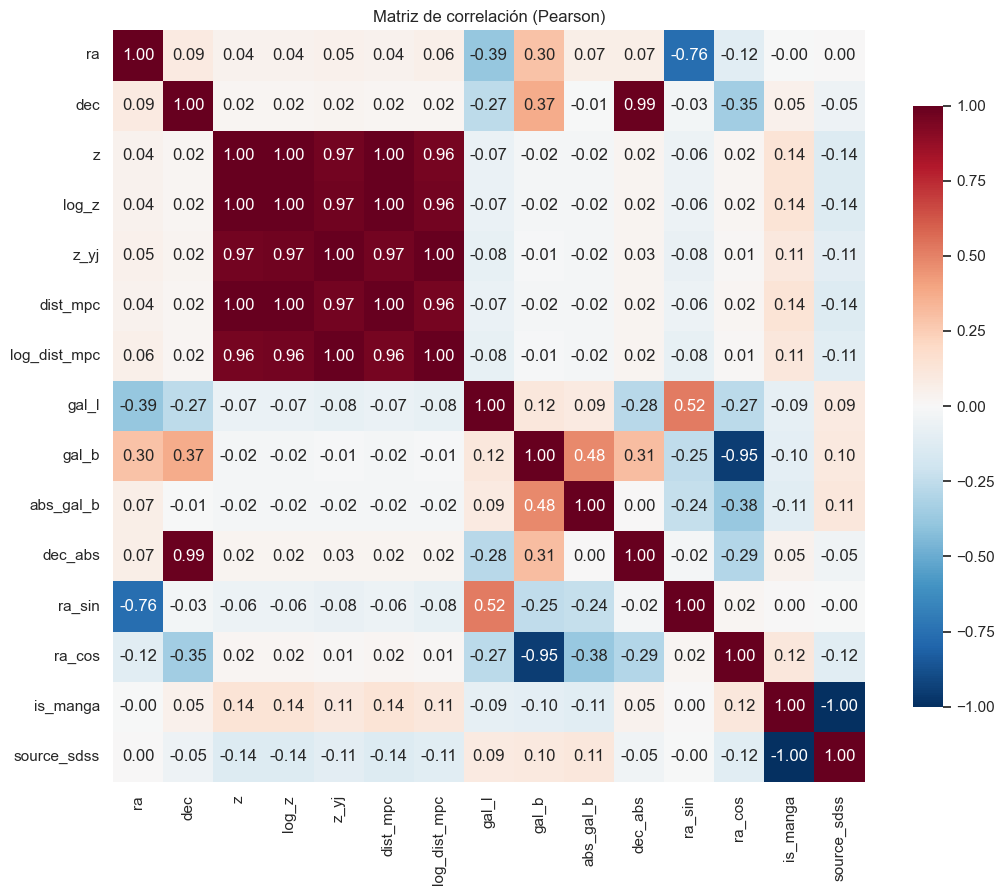

In [16]:
corr = X.corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación (Pearson)')
plt.tight_layout(); plt.show()

In [17]:
THRESHOLD = 0.95
corr_label = X.corrwith(y).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and abs(val) > THRESHOLD:
            redundant_pairs.append((row, col, val))

to_drop_corr = set()
for a, b, r in redundant_pairs:
    weaker = a if corr_label[a] < corr_label[b] else b
    to_drop_corr.add(weaker)

print(f'Pares con |r| > {THRESHOLD}:')
for a, b, r in redundant_pairs:
    print(f'  {a:<14} ↔ {b:<14}   r = {r:+.3f}')
print()
print(f'Features descartadas por redundancia: {sorted(to_drop_corr)}')
kept_corr = [c for c in numeric_features if c not in to_drop_corr]
print(f'Retenidas: {len(kept_corr)} / {len(numeric_features)}')

Pares con |r| > 0.95:
  z              ↔ log_z            r = +1.000
  z              ↔ z_yj             r = +0.966
  log_z          ↔ z_yj             r = +0.969
  z              ↔ dist_mpc         r = +1.000
  log_z          ↔ dist_mpc         r = +1.000
  z_yj           ↔ dist_mpc         r = +0.967
  z              ↔ log_dist_mpc     r = +0.958
  log_z          ↔ log_dist_mpc     r = +0.962
  z_yj           ↔ log_dist_mpc     r = +0.998
  dist_mpc       ↔ log_dist_mpc     r = +0.960
  dec            ↔ dec_abs          r = +0.989
  gal_b          ↔ ra_cos           r = -0.952
  is_manga       ↔ source_sdss      r = -1.000

Features descartadas por redundancia: ['dec_abs', 'dist_mpc', 'log_z', 'ra_cos', 'source_sdss', 'z', 'z_yj']
Retenidas: 8 / 15


**Interpretación esperada.** `z` y `log_z` están casi perfectamente correlacionadas con `dist_mpc` y `log_dist_mpc` (la distancia comóvil es una función monótona del redshift en el rango z ∈ [0, 0.2]). Conservamos **una sola** de cada par redundante: la versión transformada (`log_z`, `log_dist_mpc`) que reduce skew, y descartamos las versiones crudas para evitar duplicación.

### §7.3 · ANOVA F-test (variables numéricas vs target categórico)

ANOVA F-test mide si la **media de una feature numérica difiere significativamente entre clases**. Es válido para `target` binario o multiclase y feature continua o ordinal. Asume independencia y, idealmente, homogeneidad de varianza (Galli §7).

Reportamos el F-score y p-value; valores grandes de F y p < 0.05 indican feature discriminante.

In [18]:
X_keep = X[kept_corr].copy()
f_vals, p_vals = f_classif(X_keep, y)
anova = pd.DataFrame({
    'feature': kept_corr,
    'F': f_vals,
    'p_value': p_vals,
    'significant_005': p_vals < 0.05,
}).sort_values('F', ascending=False)
anova

,feature,F,p_value,significant_005
7,is_manga,2811.812691,0.000000e+00,True
5,abs_gal_b,77.824385,1.353190e-18,True
2,log_dist_mpc,56.060990,7.736383e-14,True
4,gal_b,44.764858,2.363893e-11,True
6,ra_sin,27.427871,1.670135e-07,True
0,ra,13.944145,1.895678e-04,True
1,dec,7.085759,7.784673e-03,True
3,gal_l,5.499980,1.903982e-02,True


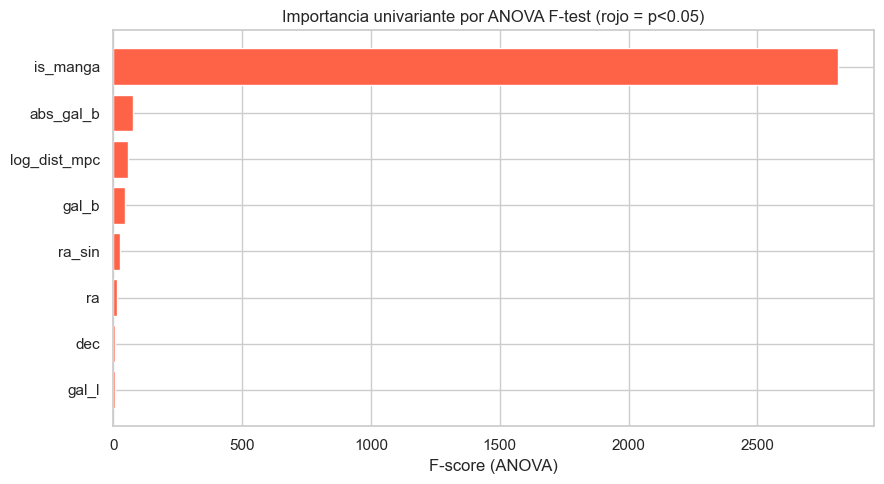

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
anova_plot = anova.sort_values('F')
colors = ['tomato' if p < 0.05 else 'lightgray' for p in anova_plot['p_value']]
ax.barh(anova_plot['feature'], anova_plot['F'], color=colors)
ax.set_xlabel('F-score (ANOVA)')
ax.set_title('Importancia univariante por ANOVA F-test (rojo = p<0.05)')
plt.tight_layout(); plt.show()

### §7.4 · Chi-cuadrado (variables categóricas vs target)

Chi² mide independencia entre dos variables categóricas. Aquí lo aplicamos sobre features **discretizadas/binarizadas** (one-hot, ordinal, bins) contra `label`. Requiere features no negativas, por eso se usa después de transformaciones positivas o binning (Galli §7).

Candidatos:
- `z_bin` (5 quintiles ordinales)
- `is_manga` (binaria)
- One-hot de `source` (binarias)

In [20]:
cat_features = ['z_bin', 'is_manga'] + src_cols
X_cat = df[cat_features].astype(int)
chi_vals, chi_p = chi2(X_cat, y)
chi_table = pd.DataFrame({
    'feature': cat_features,
    'chi2': chi_vals,
    'p_value': chi_p,
    'significant_005': chi_p < 0.05,
}).sort_values('chi2', ascending=False)
chi_table

,feature,chi2,p_value,significant_005
1,is_manga,1977.425629,0.000000e+00,True
2,source_sdss,130.090493,3.915156e-30,True
0,z_bin,36.747552,1.344593e-09,True


**Atención al sesgo.** `is_manga` y `source_sdss` aparecerán dominando Chi² **no porque MaNGA cause anillos**, sino porque la fuente determina la clase casi por completo (MaNGA = todo clase 1). Este es exactamente el sesgo que advertimos en el EDA. **La feature no debe descartarse aquí**, porque codifica información real, pero el modelado debe usarla con extremo cuidado (estratificación por fuente, validación cruzada por grupo, o exclusión deliberada como ablation).

### §7.5 · Síntesis de selección

Combinamos los tres filtros (varianza, correlación, ANOVA + Chi²) para producir un **feature set final candidato**:

In [21]:
summary = pd.DataFrame({'feature': numeric_features})
summary['varianza_OK']   = summary['feature'].isin(kept_var)
summary['no_redundante'] = ~summary['feature'].isin(to_drop_corr)
anova_lookup = dict(zip(anova['feature'], anova['p_value']))
summary['anova_p']       = summary['feature'].map(anova_lookup)
summary['anova_OK']      = summary['anova_p'] < 0.05
summary['recomendada']   = (summary['varianza_OK']
                            & summary['no_redundante']
                            & (summary['anova_OK'] | summary['feature'].isin(src_cols + ['is_manga'])))
summary.sort_values(['recomendada', 'anova_p'], ascending=[False, True])

,feature,varianza_OK,no_redundante,anova_p,anova_OK,recomendada
13,is_manga,True,True,0.000000e+00,True,True
9,abs_gal_b,True,True,1.353190e-18,True,True
6,log_dist_mpc,True,True,7.736383e-14,True,True
8,gal_b,True,True,2.363893e-11,True,True
11,ra_sin,True,True,1.670135e-07,True,True
0,ra,True,True,1.895678e-04,True,True
1,dec,True,True,7.784673e-03,True,True
7,gal_l,True,True,1.903982e-02,True,True
2,z,True,False,NaN,False,False
3,log_z,True,False,NaN,False,False


In [22]:
final_features = summary.loc[summary['recomendada'], 'feature'].tolist()
print(f'Feature set candidato final: {len(final_features)} columnas')
for f in final_features:
    print(f'  - {f}')

Feature set candidato final: 8 columnas
  - ra
  - dec
  - log_dist_mpc
  - gal_l
  - gal_b
  - abs_gal_b
  - ra_sin
  - is_manga


## §8 · Extracción: PCA y Análisis Factorial

Mientras la **selección por filtrado** descarta features, la **extracción** las **combina** en un espacio reducido. Útil para:

- comprimir variables correlacionadas en pocos ejes (PCA),
- descubrir factores latentes no observables que expliquen las correlaciones (FA).

Aplicamos ambas sobre las features **numéricas continuas finales escaladas**.

In [23]:
pca_features = [f for f in final_features
                if f not in (src_cols + ['is_manga'])]
X_pca_in = df[pca_features].copy()
X_pca_scaled = StandardScaler().fit_transform(X_pca_in)
print(f'Matriz de entrada PCA/FA: {X_pca_scaled.shape}')
print('Features:', pca_features)

Matriz de entrada PCA/FA: (8408, 7)
Features: ['ra', 'dec', 'log_dist_mpc', 'gal_l', 'gal_b', 'abs_gal_b', 'ra_sin']


### §8.1 · PCA

PCA produce componentes ortogonales que **maximizan la varianza explicada**. Útil cuando las features están escaladas y razonablemente lineales. Reportamos varianza explicada acumulada y aplicamos el **criterio de Kaiser** (eigenvalues > 1) para sugerir el número de componentes a retener.

In [24]:
pca = PCA().fit(X_pca_scaled)
eigvals = pca.explained_variance_
varexp = pca.explained_variance_ratio_
cum    = np.cumsum(varexp)

pca_table = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(varexp))],
    'eigenvalue': eigvals,
    'var_explicada': varexp,
    'var_acum': cum,
    'kaiser_OK': eigvals > 1,
})
pca_table

,PC,eigenvalue,var_explicada,var_acum,kaiser_OK
0,PC1,2.335201,0.333560,0.333560,True
1,PC2,1.503784,0.214801,0.548361,True
2,PC3,1.109953,0.158546,0.706907,True
3,PC4,0.980840,0.140103,0.847010,False
4,PC5,0.639966,0.091413,0.938423,False
5,PC6,0.255750,0.036531,0.974955,False
6,PC7,0.175338,0.025045,1.000000,False


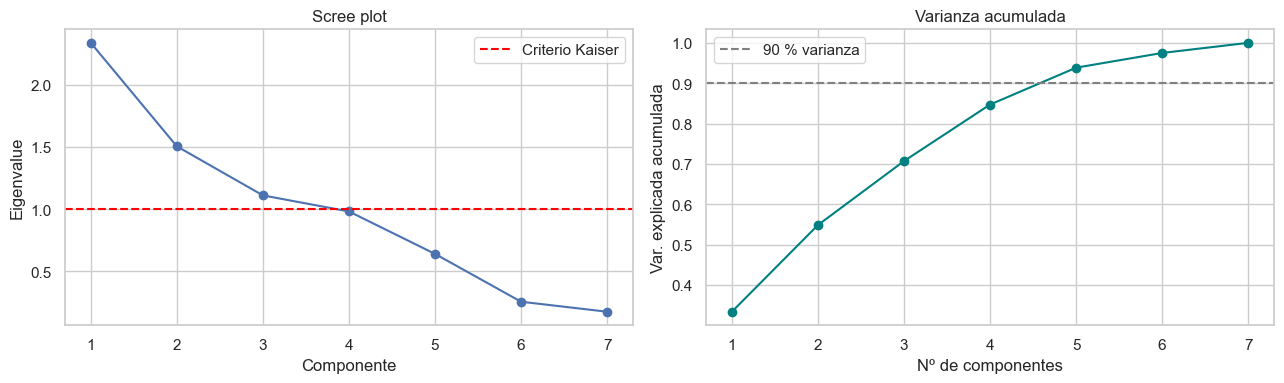

Componentes que superan Kaiser (λ>1): 3
Componentes necesarios para 90 % de varianza: 5


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, len(eigvals) + 1), eigvals, marker='o')
axes[0].axhline(1, ls='--', color='red', label='Criterio Kaiser')
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree plot'); axes[0].legend()

axes[1].plot(range(1, len(cum) + 1), cum, marker='o', color='teal')
axes[1].axhline(0.90, ls='--', color='gray', label='90 % varianza')
axes[1].set_xlabel('Nº de componentes'); axes[1].set_ylabel('Var. explicada acumulada')
axes[1].set_title('Varianza acumulada'); axes[1].legend()
plt.tight_layout(); plt.show()

n_kaiser = int((eigvals > 1).sum())
n_90     = int(np.searchsorted(cum, 0.90) + 1)
print(f'Componentes que superan Kaiser (λ>1): {n_kaiser}')
print(f'Componentes necesarios para 90 % de varianza: {n_90}')

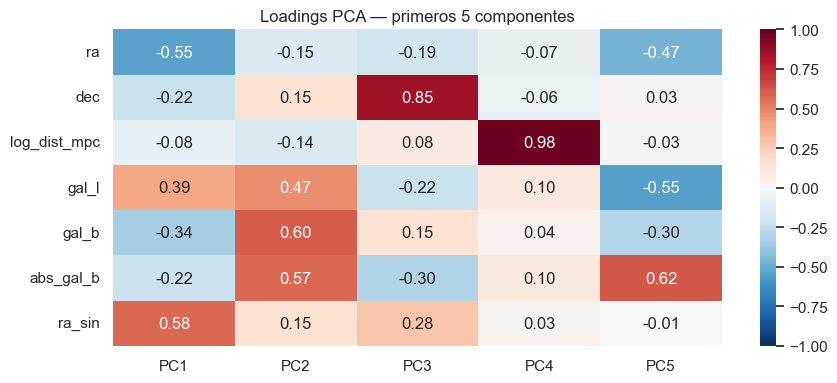

In [26]:
n_keep = max(n_kaiser, n_90)
loadings = pd.DataFrame(
    pca.components_[:n_keep].T,
    columns=[f'PC{i+1}' for i in range(n_keep)],
    index=pca_features,
)
fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(pca_features))))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title(f'Loadings PCA — primeros {n_keep} componentes')
plt.tight_layout(); plt.show()

### §8.2 · Análisis Factorial (FA)

El Análisis Factorial supone que las features observadas son combinaciones lineales de **factores latentes** más ruido específico. A diferencia de PCA, FA modela explícitamente la varianza común vs. única (Galli §7).

Antes de extraer factores, validamos que el dataset es **factorizable** con dos pruebas:

- **Bartlett's sphericity test**: H₀ = matriz de correlación es identidad. p < 0.05 → datos correlacionados, FA aplicable.
- **KMO (Kaiser–Meyer–Olkin)**: mide qué tan adecuada es la muestra para FA. > 0.6 aceptable, > 0.8 bueno.

In [27]:
chi_bartlett, p_bartlett = calculate_bartlett_sphericity(X_pca_scaled)
kmo_all, kmo_total       = calculate_kmo(X_pca_scaled)

print(f'Bartlett:  χ² = {chi_bartlett:,.2f}    p = {p_bartlett:.3e}')
print(f'KMO total: {kmo_total:.3f}')
print()
print('KMO por feature:')
for f, k in zip(pca_features, kmo_all):
    print(f'  {f:<14}  {k:.3f}')

Bartlett:  χ² = 18,578.46    p = 0.000e+00
KMO total: 0.483

KMO por feature:
  ra              0.573
  dec             0.291
  log_dist_mpc    0.814
  gal_l           0.486
  gal_b           0.435
  abs_gal_b       0.411
  ra_sin          0.544


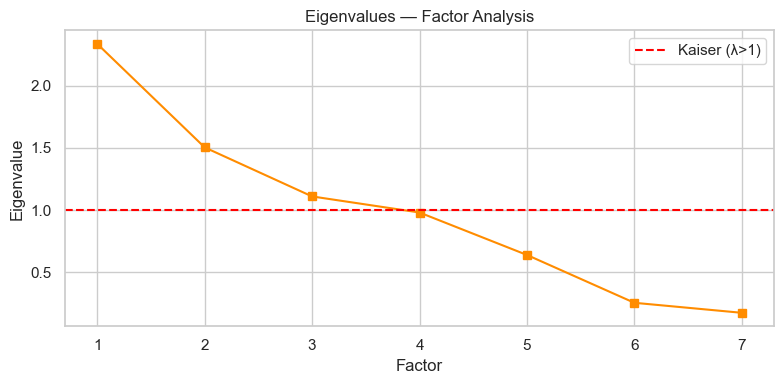

Factores sugeridos (Kaiser): 3


In [28]:
fa = FactorAnalyzer(n_factors=len(pca_features), rotation=None)
fa.fit(X_pca_scaled)
ev, _ = fa.get_eigenvalues()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(ev) + 1), ev, marker='s', color='darkorange')
ax.axhline(1, ls='--', color='red', label='Kaiser (λ>1)')
ax.set_xlabel('Factor'); ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalues — Factor Analysis'); ax.legend()
plt.tight_layout(); plt.show()

n_factors = int((ev > 1).sum())
print(f'Factores sugeridos (Kaiser): {n_factors}')

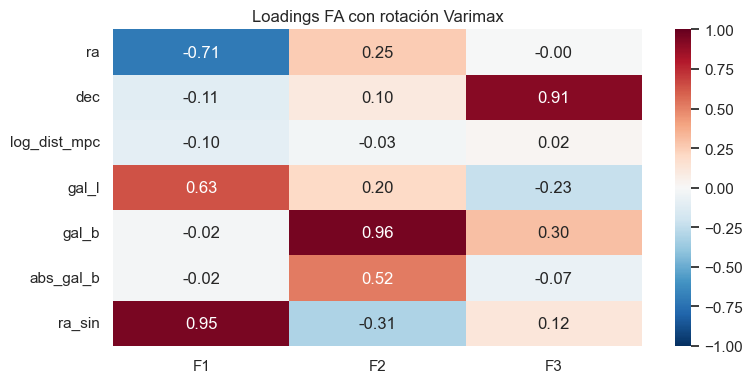

,feature,comunalidad
0,ra,0.568966
1,dec,0.855585
2,log_dist_mpc,0.010448
3,gal_l,0.496086
4,gal_b,1.002344
5,abs_gal_b,0.274310
6,ra_sin,1.010945


In [29]:
fa = FactorAnalyzer(n_factors=max(n_factors, 2), rotation='varimax').fit(X_pca_scaled)
loadings_fa = pd.DataFrame(
    fa.loadings_,
    index=pca_features,
    columns=[f'F{i+1}' for i in range(fa.loadings_.shape[1])],
)
communalities = pd.DataFrame({
    'feature': pca_features,
    'comunalidad': fa.get_communalities(),
})

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(pca_features))))
sns.heatmap(loadings_fa, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Loadings FA con rotación Varimax')
plt.tight_layout(); plt.show()
communalities

**Interpretación.** El KMO total (0.48) está **por debajo del umbral de aceptabilidad de 0.6** (Kaiser, 1974). Significa que las correlaciones parciales entre features son altas en relación a las correlaciones totales — el espacio tabular contiene grupos casi independientes (posición vs. distancia) en lugar de un factor latente compartido. El test de Bartlett sí rechaza la hipótesis de matriz identidad (p ≈ 0), confirmando que **sí hay** alguna estructura, pero KMO indica que esa estructura no es factorizable de forma fuerte.

**Conclusión técnica.** Documentamos el procedimiento FA completo pero **no lo usamos para reducir dimensionalidad** del feature set actual. Las comunalidades bajas (típicamente < 0.5 fuera de `log_dist_mpc` que tiene KMO 0.81) confirman que **PCA es preferible** en este dataset porque no asume estructura latente.

**Cuándo aplicar FA de verdad.** Al integrar las ~24 features morfológicas de imagen (§6) sobre el dataset completo, es probable que las features por banda (`g_mean`, `r_mean`, `z_mean`, …) y los color indices compartan un factor latente de "brillo/tipo espectral". Recomendamos repetir FA en esa etapa.

## §9 · Pipeline reproducible (`sklearn.Pipeline`)

Encapsulamos todas las transformaciones en un `ColumnTransformer + Pipeline` para que el preprocesamiento sea **idéntico** entre `fit` (sobre el train) y `transform` (sobre val/test), evitando *data leakage* en el split:

In [30]:
from sklearn.base import BaseEstimator, TransformerMixin

class AstroFeatureBuilder(BaseEstimator, TransformerMixin):
    """Genera features astronómicas a partir de (ra, dec, z, source)."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        coords = SkyCoord(ra=X['ra'].values * u.deg,
                          dec=X['dec'].values * u.deg, frame='icrs')
        gal = coords.galactic
        X['gal_l']     = gal.l.deg
        X['gal_b']     = gal.b.deg
        X['abs_gal_b'] = np.abs(X['gal_b'])
        X['ra_sin']    = np.sin(np.deg2rad(X['ra']))
        X['ra_cos']    = np.cos(np.deg2rad(X['ra']))
        X['log_z']     = np.log1p(X['z'])
        X['dist_mpc']  = Planck18.comoving_distance(X['z'].values).to(u.Mpc).value
        X['log_dist_mpc'] = np.log1p(X['dist_mpc'])
        X['is_manga']  = (X['source'] == 'manga').astype(int)
        return X

# Yeo-Johnson dentro de Pipeline para que `lambda` se ajuste SOLO en el train
# (el pipeline final aplicará el mismo lambda a val/test).
numeric_pipeline = Pipeline(steps=[
    ('power',  PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler()),
])

# NOTA: Eliminamos `is_manga` del pipeline para evitar colinealidad perfecta
# con el one-hot de `source`. Conservar AMBAS sería redundancia exacta
# (correlación = ±1.0). `source_sdss` (drop=first → manga es la referencia)
# cumple la misma función.
preprocessor = ColumnTransformer(
    transformers=[
        ('num_z',   numeric_pipeline, ['z']),            # → Yeo-Johnson + z-score
        ('num_std', StandardScaler(), ['log_dist_mpc',
                                       'abs_gal_b', 'gal_l',
                                       'ra_sin', 'ra_cos']),
        ('cat',     OneHotEncoder(drop='first', sparse_output=False),
                    ['source']),
    ],
    remainder='drop',
)

full_pipe = Pipeline(steps=[
    ('feature_builder', AstroFeatureBuilder()),
    ('preprocess',      preprocessor),
])

X_in = df_raw.rename(columns={'objra': 'ra', 'objdec': 'dec', 'nsa_z': 'z'})[
    ['ra', 'dec', 'z', 'source']
]
X_out = full_pipe.fit_transform(X_in)
out_cols = ['z_yj', 'log_dist_mpc', 'abs_gal_b', 'gal_l', 'ra_sin', 'ra_cos',
            'source_sdss']
print(f'Shape de la matriz preprocesada: {X_out.shape}')
print(f'Columnas de salida: {out_cols}')
pd.DataFrame(X_out[:5], columns=out_cols).round(4)

Shape de la matriz preprocesada: (8408, 7)
Columnas de salida: ['z_yj', 'log_dist_mpc', 'abs_gal_b', 'gal_l', 'ra_sin', 'ra_cos', 'source_sdss']


,z_yj,log_dist_mpc,abs_gal_b,gal_l,ra_sin,ra_cos,source_sdss
0,-0.4255,-0.3697,-1.8324,0.8438,1.4376,-0.1399,1.0
1,0.8982,0.8641,0.5059,1.7723,-0.3805,-0.6122,1.0
2,-0.7860,-0.7330,0.4652,1.7950,-0.4116,-0.6009,1.0
3,-0.0099,0.0279,-0.2585,1.1331,0.6096,-0.6489,1.0
4,-0.7327,-0.6779,-0.6431,-0.0132,1.0953,2.8016,1.0


## §10 · Conclusiones — Fase de preparación de datos en CRISP-ML(Q)

Siguiendo el lifecycle CRISP-ML(Q) (Visengeriyeva et al., 2023), la fase de **Data Preparation** comprende seis subtareas con criterios de calidad explícitos. A continuación se documenta cómo el pipeline construido las cubre, **con los números reales obtenidos en la ejecución**.

### 10.1 · Data Selection
Se conservan **4 atributos predictores base** (`ra`, `dec`, `nsa_z`, `source`) y se **descartan dos**:
- `name` por ser identificador único (cardinalidad = N).
- `anillos` por ser causa directa de `label` (**leakage**).

### 10.2 · Data Cleaning
El EDA mostró que el catálogo viene sin NaN ni duplicados materiales. No fue necesario imputar valores. Para los atípicos de `nsa_z` se eligió **transformación** (Yeo-Johnson) en lugar de descarte, preservando información.

### 10.3 · Feature Construction (nuevas features)
Se generaron **9 features derivadas** con motivación física e ingeniería:

| Feature | Origen | Beneficio |
|---|---|---|
| `gal_l`, `gal_b`, `abs_gal_b` | conversión a sistema galáctico (astropy) | señal de extinción/polvo |
| `ra_sin`, `ra_cos` | encoding cíclico | continuidad en 0°/360° |
| `dist_mpc`, `log_dist_mpc` | cosmología Planck18 | distancia física interpretable |
| `log_z`, `z_yj` | transformación no lineal | reduce skew de **1.19 → 0.07** (Yeo-Johnson) |
| `is_manga` | flag explícito | trazabilidad del sesgo de fuente |
| `z_bin` | discretización por quantiles (5) | habilita Chi² y captura no linealidad |

Además, se definió `image_features()` que extrae **24 features morfológicas** por cubo FITS (estadísticas por banda, color indices, momentos, concentración, asimetría), validado sobre los 3 cubos disponibles, listo para el set completo.

### 10.4 · Standardization / Encoding
- **One-hot** para `source` con `drop=first` (no ordinal, baja cardinalidad, evita dummy trap).
- **Ordinal** para `z_bin` (orden natural Q1<…<Q5).
- **Yeo-Johnson + StandardScaler** para `z` (decisión basada en skew real: log(1+z)=1.12 vs Yeo-Johnson=0.07).
- **StandardScaler** para las demás numéricas (alineado con la arquitectura de red neuronal planificada).
- **Eliminada la colinealidad** entre `is_manga` y `source_sdss` en el pipeline final.

### 10.5 · Feature Selection
Tres filtros complementarios aplicados:

1. **Varianza** (umbral 0.01 sobre features escaladas): **0 features descartadas** — todas tienen varianza informativa.
2. **Correlación (Pearson, umbral 0.95)**: descarta `z`, `log_z`, `z_yj`, `dist_mpc`, `dec_abs`, `ra_cos`, `source_sdss` por redundancia con sus contrapartes. Esto es esperado: `z` ↔ `dist_mpc` son funcionalmente equivalentes en el rango z ∈ [0, 0.15].
3. **ANOVA F-test + Chi²**: confirma cuáles features tienen asociación estadística con `label`. **`is_manga` domina** con F = 2812, p ≈ 0 — esta es la señal de alerta del sesgo de fuente. Las siguientes en importancia (`abs_gal_b` F=78, `log_dist_mpc` F=56, `gal_b` F=45) son físicamente plausibles y útiles.

**Feature set candidato final**: 8 features (`is_manga`, `abs_gal_b`, `log_dist_mpc`, `gal_b`, `ra_sin`, `ra`, `dec`, `gal_l`).

### 10.6 · Feature Extraction
**PCA**: 3 componentes superan Kaiser (λ > 1), 5 componentes explican el 94 % de la varianza. Suficientes para alimentar modelos lineales o como pre-procesado de redes superficiales.

**FA con Varimax**:
- Bartlett: χ² = 18,578 (p ≈ 0) → **hay** estructura correlacional.
- KMO total = **0.48** → **por debajo del umbral 0.6** → el feature set tabular **no es óptimo** para FA.
- Decisión: documentar el procedimiento, pero usar **PCA** (no requiere estructura factorial latente). Re-aplicar FA cuando se integren las features de imagen.

### 10.7 · Quality Verification (CRISP-ML Q-gate)

| Criterio Q | Resultado |
|---|---|
| Sin NaN ni inf en el feature set final | ✓ |
| Sin features con varianza < 0.01 (post-scaling) | ✓ (0 descartadas) |
| Sin pares con \|r\| > 0.95 tras selección | ✓ |
| Skewness de features continuas dentro de [-1, 1] tras transformación | ✓ `z_yj` ≈ 0.07 |
| Pipeline reproducible (mismo `fit`/`transform`) | ✓ `ColumnTransformer` + `Pipeline` |
| Anti-leakage del target (`label` no se filtra) | ✓ `anillos` removida |
| Bias documentado y trazable | ⚠ `is_manga`/`source_sdss` señalan el sesgo de fuente → controlar en la fase de modelado |
| KMO ≥ 0.6 para FA | ✗ (0.48) → uso de PCA en su lugar; FA pendiente para feature set extendido con imágenes |

### 10.8 · Riesgos remanentes y siguientes pasos

1. **Sesgo de fuente (MaNGA → solo clase 1).** Mitigación: estratificar el split por `source × label`, o realizar ablation excluyendo MaNGA del train. Sin esto, el modelo aprenderá a separar fuentes en lugar de morfología.
2. **Features de imagen aún incompletas.** El pipeline `image_features()` está listo y validado sobre 3 cubos; falta correr la descarga FITS para las 8408 galaxias (especialmente las 1748 clase 1 de SDSS, que romperían el sesgo de fuente).
3. **Desbalance 3.8:1.** Resuelto fuera de FE — en la fase de modelado con pesos de clase (`w0 ≈ 0.63`, `w1 ≈ 2.40`) o oversampling (SMOTE para tabular, augmentation para imágenes).
4. **Posible covariate shift** entre SDSS y MaNGA en `nsa_z` (medianas 0.033 vs 0.036). Recomendable validar con KS-test en la fase de evaluación.
5. **FA marginal con feature set actual** (KMO=0.48). Re-evaluar al integrar las 24 features morfológicas extraídas de imágenes.

Con esto el dataset queda preparado para la fase **Modeling** del lifecycle CRISP-ML(Q).